In [31]:
from astroquery.sdss import SDSS
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-deep')


# Part I: AGN Diagnostics using narrow emission lines

In [32]:
query = """
        SELECT
        s.specobjid, s.class, s.subclass,
        2.3548 * sigma_balmer AS fwhm_hbeta,
        2.3548 * oiii_sigma AS fwhm_oiii,
        g.oiii_5007_flux, g.oiii_5007_flux_err, g.oiii_5007_eqw, 
        g.h_beta_flux, g.h_beta_flux_err, g.h_beta_eqw,
        g.h_alpha_flux, g.h_alpha_flux_err, g.h_alpha_eqw,
        g.nii_6584_flux, g.nii_6584_flux_err, g.nii_6584_eqw,
        g.oiii_5007_flux / g.h_beta_flux AS oiii_hbeta_ratio,
        g.nii_6584_flux / g.h_alpha_flux AS nii_halpha_ratio

        FROM SpecObj as s
        JOIN GalSpecLine as g ON s.specobjid = g.specobjid

        WHERE
        (s.class = 'GALAXY' OR s.class = 'QSO') AND
        s.snmedian_g > 40 AND
        2.3548 * sigma_balmer < 500 AND
        2.3548 * oiii_sigma < 500 AND
        g.oiii_5007_eqw < -0.1 AND
        g.h_beta_eqw < -0.1 AND
        g.h_alpha_eqw < -0.1 AND
        g.nii_6584_eqw < -0.1 AND
        g.oiii_5007_flux > 5 AND
        g.h_beta_flux > 5 AND
        g.h_alpha_flux > 5 AND
        g.nii_6584_flux > 5 AND
        g.oiii_5007_flux > 5 * g.oiii_5007_flux_err AND
        g.h_beta_flux > 5 * g.h_beta_flux_err AND
        g.h_alpha_flux > 5 * g.h_alpha_flux_err AND
        g.nii_6584_flux > 5 *g.nii_6584_flux_err
        """

In [33]:
result = SDSS.query_sql(query, context='DR18').to_pandas()
result.head()

,specobjid,class,subclass,fwhm_hbeta,fwhm_oiii,oiii_5007_flux,oiii_5007_flux_err,oiii_5007_eqw,h_beta_flux,h_beta_flux_err,h_beta_eqw,h_alpha_flux,h_alpha_flux_err,h_alpha_eqw,nii_6584_flux,nii_6584_flux_err,nii_6584_eqw,oiii_hbeta_ratio,nii_halpha_ratio
0,338924766721239040,GALAXY,BROADLINE,478.1871,442.5101,78.39893,9.146924,-0.730471,45.66092,9.089925,-0.336793,135.2715,13.439960,-0.996696,155.3322,12.571270,-1.178219,1.716981,1.148299
1,338991287174719488,GALAXY,STARFORMING,275.2300,301.8552,324.13890,8.940432,-3.130040,589.44490,9.630146,-5.363711,2299.2290,20.399490,-21.505370,1348.4960,14.539490,-12.316170,0.549905,0.586499
2,340022899698067456,GALAXY,STARFORMING,375.6640,426.7946,638.90770,14.497860,-4.142563,1519.60100,17.748480,-9.316946,6541.7730,44.785820,-41.429770,3709.2260,28.834340,-22.952280,0.420444,0.567006
3,389691963177199616,GALAXY,NaN,368.8243,343.3826,108.34530,6.690306,-1.261482,63.04348,6.553440,-0.639528,168.1538,8.990896,-1.454268,242.2146,8.756283,-2.123575,1.718580,1.440435
4,392955038911195136,GALAXY,STARFORMING,324.0412,285.5166,44.03122,2.895383,-0.877409,212.14120,3.265459,-4.491336,1010.6390,5.867961,-22.689670,412.7115,3.994951,-9.181781,0.207556,0.408367


In [34]:
result.to_csv('result_1.csv', index=False)

In [35]:
print("Number of objects retrieved:", len(result))

Number of objects retrieved: 900


**Separation lines**

Theoretical (Kweley et al. 2001):

$$\frac{\log([OIII] λ500)}{H\beta} = \frac{0.61}{\log([NII]/H\alpha) − 0.47} + 1.19$$

Empirical (Kaufmann et al. 2003):

$$\frac{\log( [OIII] λ500)}{H\beta} = \frac{0.61}{\log([NII]/H\alpha) − 0.05} + 1.3$$

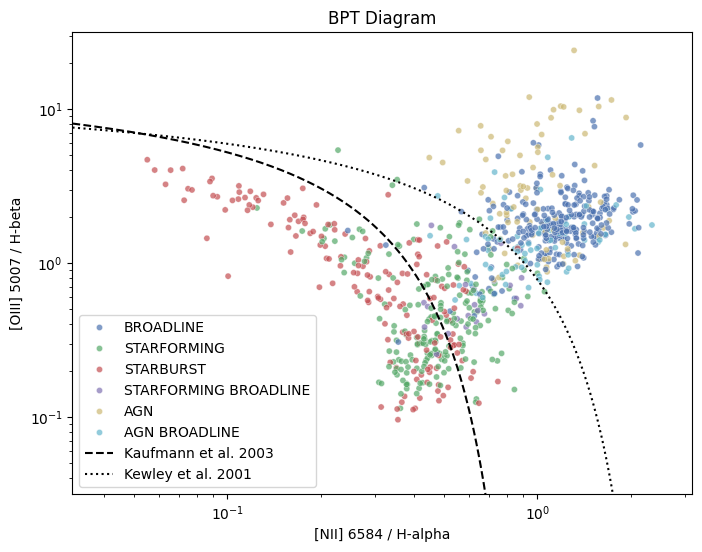

In [48]:
x_min = 10**(-1.5)
x_max = 10**(0.5)
x = np.logspace(-1.5,0.5,500)
x1 = x[x<10**0.05]
x2 = x[x<10**0.47]

plt.figure(figsize=(8,6))
sns.scatterplot(result,x='nii_halpha_ratio',y='oiii_hbeta_ratio',hue='subclass',s=20,alpha=0.7)
plt.plot(x1,10**(0.61/(np.log10(x1)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
plt.plot(x2,10**(0.61/(np.log10(x2)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
#plt.axhline(y=3,color='k')
#plt.axvline(x=0.6,color='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[NII] 6584 / H-alpha')
plt.ylabel('[OIII] 5007 / H-beta')
plt.xlim(10**-1.5, 10**0.5)
plt.ylim(10**-1.5, 10**1.5)
plt.title('BPT Diagram')
plt.legend()
plt.show()


# Part II: Classification of galaxies using mid-IR colors

In [ ]:
import sys
sys.path.append('/Users/isaac/Documents/MASS/Academic/2nd semester/AGN/tutorials/AGN-tutorials/SciScript-Python')
from SciServer import Authentication, CasJobs

Authentication.login('', '')

query2 = """
SELECT
    s.specobjid, s.class, s.subclass,
    w.w1mpro,w.w2mpro,w.w3mpro,
    w.w1mpro - w.w2mpro AS w1_w2_color,
    w.w2mpro - w.w3mpro AS w2_w3_color,
    2.3548 * sigma_balmer AS fwhm_hbeta,
    2.3548 * oiii_sigma AS fwhm_oiii,
    g.oiii_5007_flux, g.oiii_5007_flux_err, g.oiii_5007_eqw, 
    g.h_beta_flux, g.h_beta_flux_err, g.h_beta_eqw,
    g.h_alpha_flux, g.h_alpha_flux_err, g.h_alpha_eqw,
    g.nii_6584_flux, g.nii_6584_flux_err, g.nii_6584_eqw,
    g.oiii_5007_flux / g.h_beta_flux AS oiii_hbeta_ratio,
    g.nii_6584_flux / g.h_alpha_flux AS nii_halpha_ratio
    
FROM SpecObj AS s
    JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
    JOIN photoTag AS p ON s.bestobjid = p.objid
    JOIN wise_xmatch AS x ON p.objid = x.sdss_objid
    JOIN wise_allsky AS w ON x.wise_cntr = w.cntr
    
WHERE (s.class = 'GALAXY' OR s.class = 'QSO') AND
    s.snmedian_g > 40 AND
    2.3548 * sigma_balmer < 500 AND
    2.3548 * oiii_sigma < 500 AND
    g.oiii_5007_eqw < -0.1 AND
    g.h_beta_eqw < -0.1 AND
    g.h_alpha_eqw < -0.1 AND
    g.nii_6584_eqw < -0.1 AND
    g.oiii_5007_flux > 5 AND
    g.h_beta_flux > 5 AND
    g.h_alpha_flux > 5 AND
    g.nii_6584_flux > 5 AND
    g.oiii_5007_flux > 5 * g.oiii_5007_flux_err AND
    g.h_beta_flux > 5 * g.h_beta_flux_err AND
    g.h_alpha_flux > 5 * g.h_alpha_flux_err AND
    g.nii_6584_flux > 5 *g.nii_6584_flux_err
"""

# Run synchronously with CasJobs
result2 = CasJobs.executeQuery(query2, context='DR18')

In [38]:
result2.to_csv('result_2.csv', index=False)

In [39]:
result2.head()
print("Number of objects retrieved:", len(result2))

Number of objects retrieved: 886


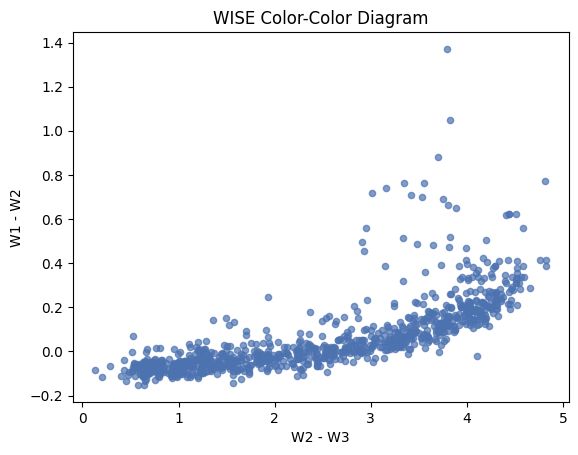

In [43]:
plt.scatter(result2['w2_w3_color'],result2['w1_w2_color'], s=20,alpha=0.7)
plt.ylabel('W1 - W2')
plt.xlabel('W2 - W3')
plt.title('WISE Color-Color Diagram')
plt.show()

Assign classes to objects

In [45]:
# spheroids w2 - w3 < 2
# intermediate disks 2 < w2 - w3 < 3.5
# SF disks w2 - w3 > 3.5
# AGN & ULIRGs w1 - w2 > 0.8

result2['type'] = 'Unknown'

result2.loc[(result2['w2_w3_color'] < 2) & (result2['w1_w2_color'] < 0.8), 'type'] = 'Spheroid'
result2.loc[(result2['w2_w3_color'] >= 2) & (result2['w2_w3_color'] < 3.5) & (result2['w1_w2_color'] < 0.8), 'type'] = 'Intermediate Disk' 
result2.loc[(result2['w2_w3_color'] >= 3.5) & (result2['w1_w2_color'] < 0.8), 'type'] = 'SF Disk'
result2.loc[result2['w1_w2_color'] >= 0.8, 'type'] = 'AGN/ULIRG'


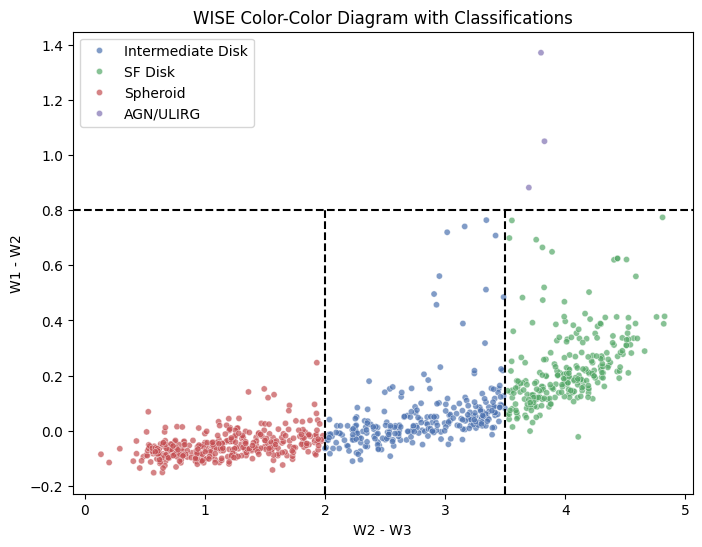

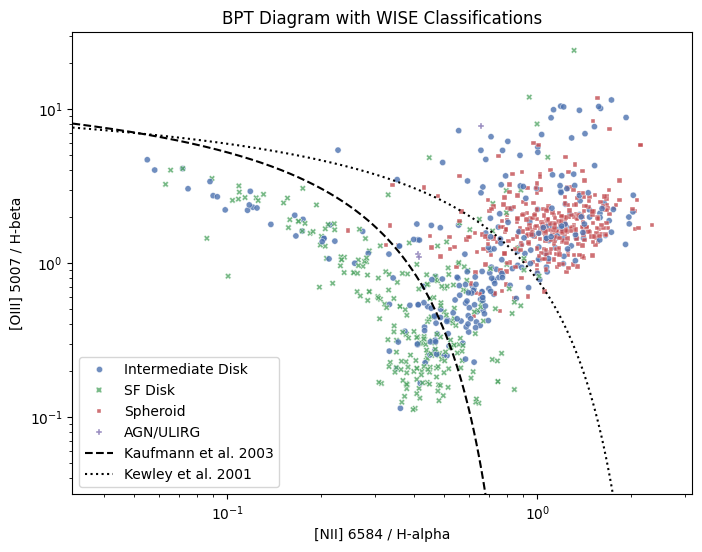

In [73]:
plt.figure(figsize=(8,6))
sns.scatterplot(result2,x='w2_w3_color',y='w1_w2_color',hue='type',s=20,alpha=0.7)
plt.xlabel('W2 - W3')
plt.ylabel('W1 - W2')
plt.axvline(x=2,ymax=0.62,color='k', linestyle='--')
plt.axvline(x=3.5,ymax=0.62,color='k', linestyle='--')
plt.axhline(y=0.8,color='k', linestyle='--')
plt.title('WISE Color-Color Diagram with Classifications')
plt.legend()

plt.figure(figsize=(8,6))
sns.scatterplot(result2,x='nii_halpha_ratio',y='oiii_hbeta_ratio',hue='type',style='type',s=20,alpha=0.8)
plt.plot(x1,10**(0.61/(np.log10(x1)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
plt.plot(x2,10**(0.61/(np.log10(x2)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[NII] 6584 / H-alpha')
plt.ylabel('[OIII] 5007 / H-beta')
plt.xlim(10**-1.5, 10**0.5)     
plt.ylim(10**-1.5, 10**1.5)
plt.title('BPT Diagram with WISE Classifications')
plt.legend()


plt.show()

Compared to the classification from the BPT diagram there are very few objects (only 3) classified as AGN or ULIRG from the WISE classification

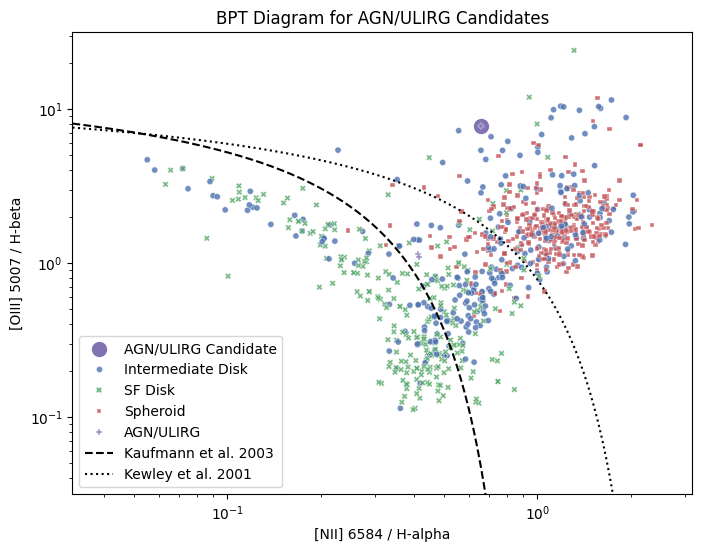

In [ ]:
# locate random object classified as AGN/ULIRG from the color-color diagram and plot them on the BPT diagram
plt.figure(figsize=(8,6))
agn_ulirg = np.random.choice(result2[result2['type'] == 'AGN/ULIRG'].index)
plt.scatter(result2.loc[agn_ulirg,'nii_halpha_ratio'],result2.loc[agn_ulirg,'oiii_hbeta_ratio'], s=100, color='C3', label='AGN/ULIRG Candidate')
sns.scatterplot(result2,x='nii_halpha_ratio',y='oiii_hbeta_ratio',hue='type',style='type',s=20,alpha=0.8)
plt.plot(x1,10**(0.61/(np.log10(x1)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
plt.plot(x2,10**(0.61/(np.log10(x2)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[NII] 6584 / H-alpha')
plt.ylabel('[OIII] 5007 / H-beta')
plt.xlim(10**-1.5, 10**0.5)     
plt.ylim(10**-1.5, 10**1.5)
plt.title('BPT Diagram for AGN/ULIRG Candidates')
plt.legend()
plt.show()

The optical classification agrees with the classification from the color-color diagram